In [ ]:
## Simple code to train Swin+yolo

In [69]:
import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
import cv2
import torch

from mammo_prep.windowing import preprocess_window
from mammo_prep.io import load_dicom
from mammo_prep.artifacts import flip_to_standard, crop_breast, resize_long_side, pad_to_square



In [4]:
## Configuration

IMAGES_DIR = Path("/home/enric/Datasets/Original/vindr/images")
CSV_PATH = Path("/home/enric/Datasets/Original/vindr/finding_annotations.csv")
LABELS_DIR = Path("/home/enric/Mammo/Lesion Detection/Yolo v8/vindr_yolo/labels")
OUTPUT_DIR = Path("/home/enric/Mammo/Lesion Detection/Yolo v8/vindr_yolo_swin/train_simple")

IMG_SIZE = 1024
BATCH_SIZE = 4
EPOCHS = 100
LR = 1e-4
NUM_WORKERS = 8
TRAIN_MAX_IMAGES = 4000
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

In [8]:
# Sample one image to check

df =pd.read_csv(CSV_PATH)
fila = df.iloc[0]
path = IMAGES_DIR / str(fila["study_id"]) / f"{fila['image_id']}.dicom"
path.exists()

True

In [54]:
# Data functions

def read_dicom(path):
    image, ds = load_dicom(path)
    if getattr(ds, "PhotometricInterpretation", "") =="MONOCHROME1":
        image = image.max() - image
    image = flip_to_standard(image, ds)
    return preprocess_window(
        image,
        dicom_dataset=ds,
        method="breast_tissue",
        voi_func="LINEAR",
        exclude_background=True,
        output_dtype=np.uint8,
    )



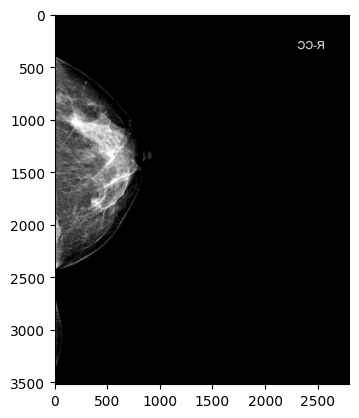

In [60]:
image= read_dicom(path)

plt.imshow(image, cmap="gray")
plt.show()

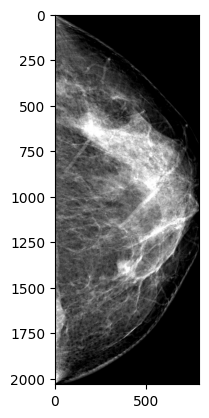

In [61]:
# Crop and resize image
image,_ = crop_breast(image)
plt.imshow(image, cmap="gray")
plt.show()

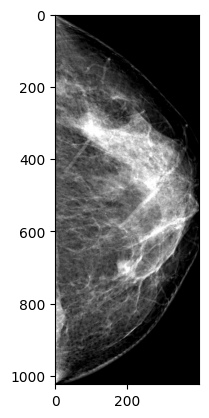

In [70]:
image = resize_long_side(image, target_size = IMG_SIZE)
plt.imshow(image, cmap="gray")
plt.show()

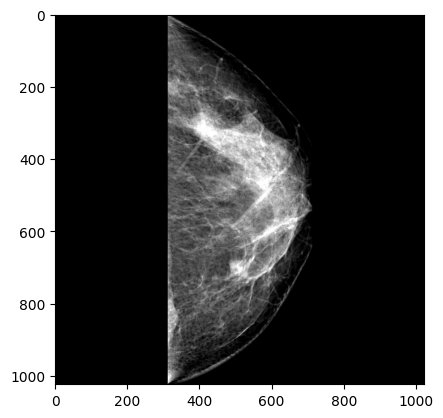

In [71]:
image = pad_to_square(image)
plt.imshow(image, cmap="gray")
plt.show()

In [72]:
def load_labels(path):
    rows = []
    for line in path.read_text().splitlines():
        if line.strip():
            rows.append([float(v) for v in line.split()])
    return np.array(rows, dtype=np.float32).reshape(-1,5)


In [73]:
labels_dir = LABELS_DIR / "train" / f"{fila['image_id']}.txt"
labels_dir

PosixPath('/home/enric/Mammo/Lesion Detection/Yolo v8/vindr_yolo/labels/train/4e3a578fe535ea4f5258d3f7f4419db8.txt')

In [74]:
a = load_labels(labels_dir) # Read the bounding boxes
a

array([[0.        , 0.86394995, 0.5094358 , 0.04565717, 0.03442581]],
      dtype=float32)

In [75]:
def resize_and_pad(image, labels, size):
    h, w = image.shape
    scale = size / max(h,w)
    new_w, new_h = round(w * scale), round(h * scale)
    resized = cv2.resize(image, (new_w, new_h))

    canvas = np.zeros((size,size), dtype=np.uint8)
    pad_x = (size - new_w) //2
    pad_y = (size - new_h) //2
    canvas[pad_y:pad_y+new_h, pad_x:pad_x+new_w] = resized

    labels = labels.copy()
    labels[:,1] = (labels[:,1] * new_w + pad_x) /size  #cx
    labels[:,2] = (labels[:,2] * new_h + pad_y) / size #cy
    labels[:,3] = labels[:,3] * new_w /size            # w
    labels[:,4] = labels[:,4] * new_h /size            # h
    return canvas, labels



In [76]:
canvas, labels2 = resize_and_pad(image, a , 1024)
print(image.shape, "->", canvas.shape)
print(a)
print(labels2)

(1024, 1024) -> (1024, 1024)
[[0.         0.86394995 0.5094358  0.04565717 0.03442581]]
[[0.         0.86394995 0.5094358  0.04565717 0.03442581]]


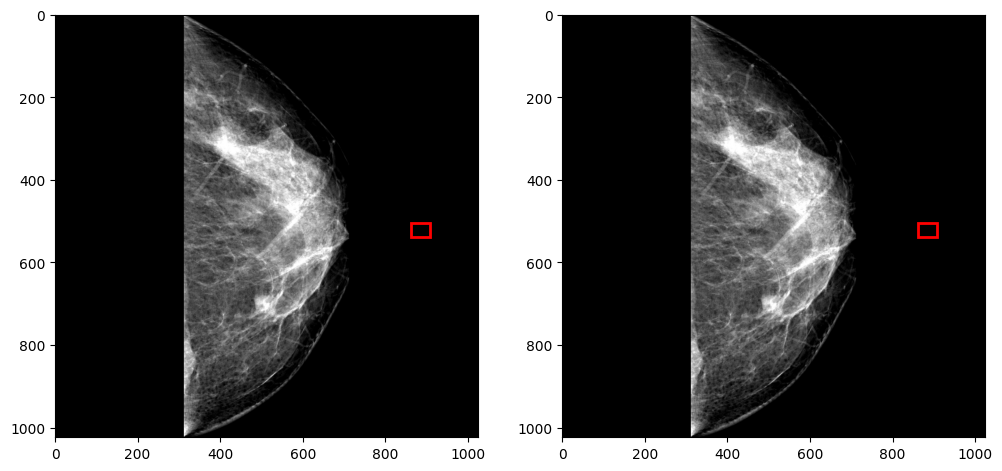

In [77]:
# Original image patch
h, w = image.shape
_, or_x,or_y, or_bw, or_bh = a[0]

x0 = (or_x - or_bw / 2) * w
y0 = (or_y - or_bh / 2) * h


# Mod image patch
_, cx, cy, bw, bh = labels2[0]

x1 = (cx-bw /2)*1024
y1 = (cy-bh /2)*1024

fig,axes = plt.subplots(1,2,figsize=(12,6))
axes[0].imshow(image, cmap="gray")
axes[0].add_patch(plt.Rectangle((x0,y0), or_bw*w, or_bh * h,
                                fill=False, edgecolor="red", linewidth=2))
axes[1].imshow(canvas, cmap="gray")
axes[1].add_patch(plt.Rectangle((x1,y1),bw * 1024, bh *1024,
                                fill=False, edgecolor="red", linewidth=2))